In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, sample_forward_process_minusx_plus_sqrt2D_dw
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

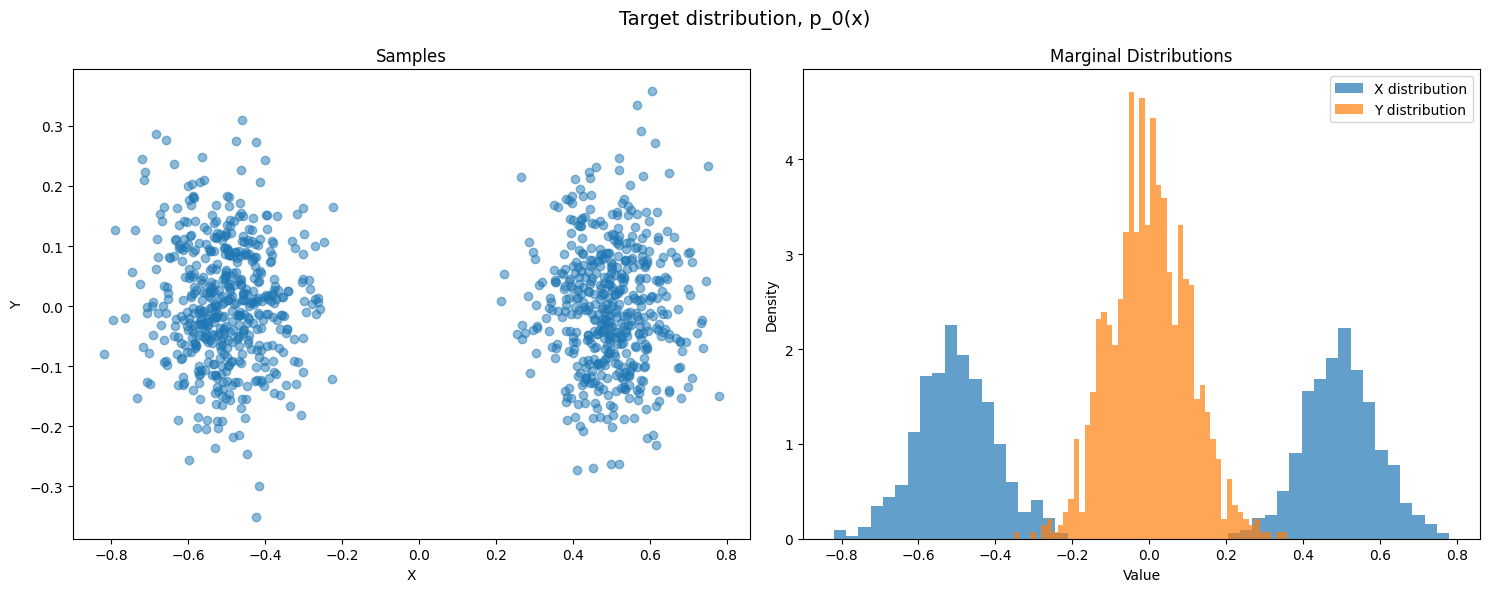

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()


plt.tight_layout()
plt.show()

In [6]:
key, subkey = jr.split(key)
t_forward = .2
samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(t_forward, n_samples, D=1, samples0=samples_0, key=subkey)

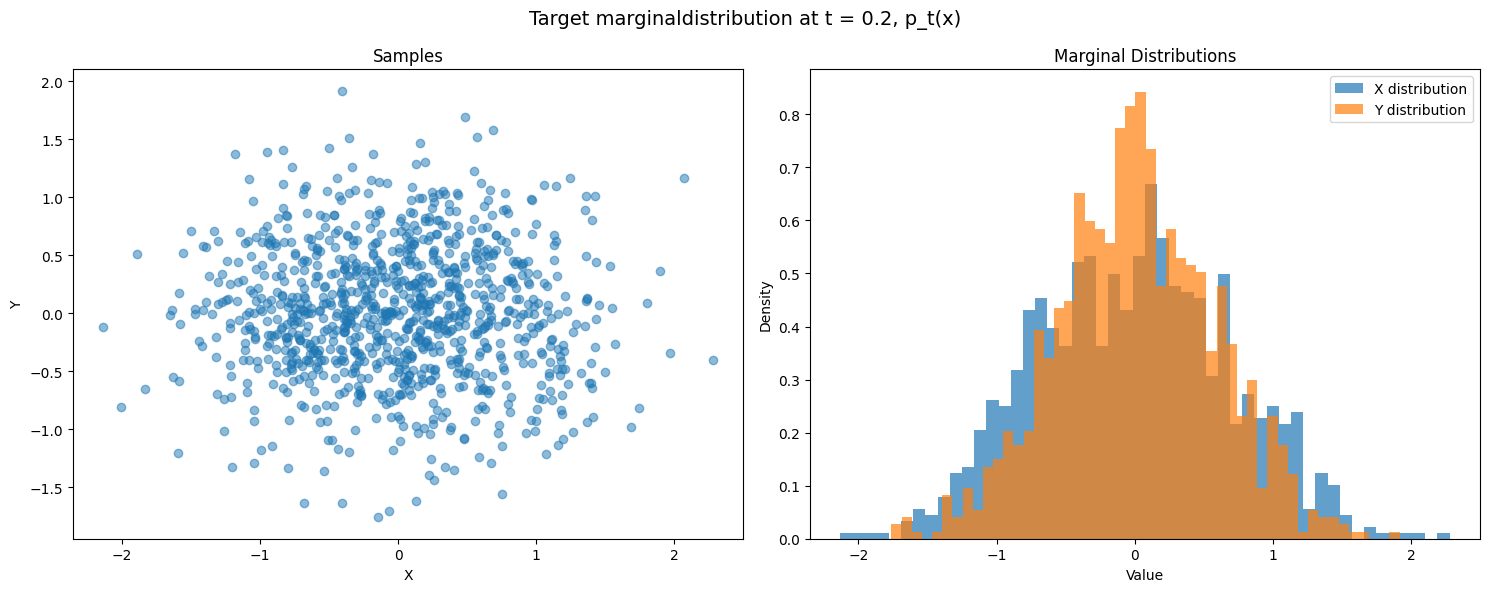

In [7]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Target marginaldistribution at t = {t_forward}, p_t(x)', fontsize=14)


# First subplot: Scatter plot of samples
ax1.scatter(samples_t[:, 0], samples_t[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_t[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_t[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [8]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [9]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [10]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


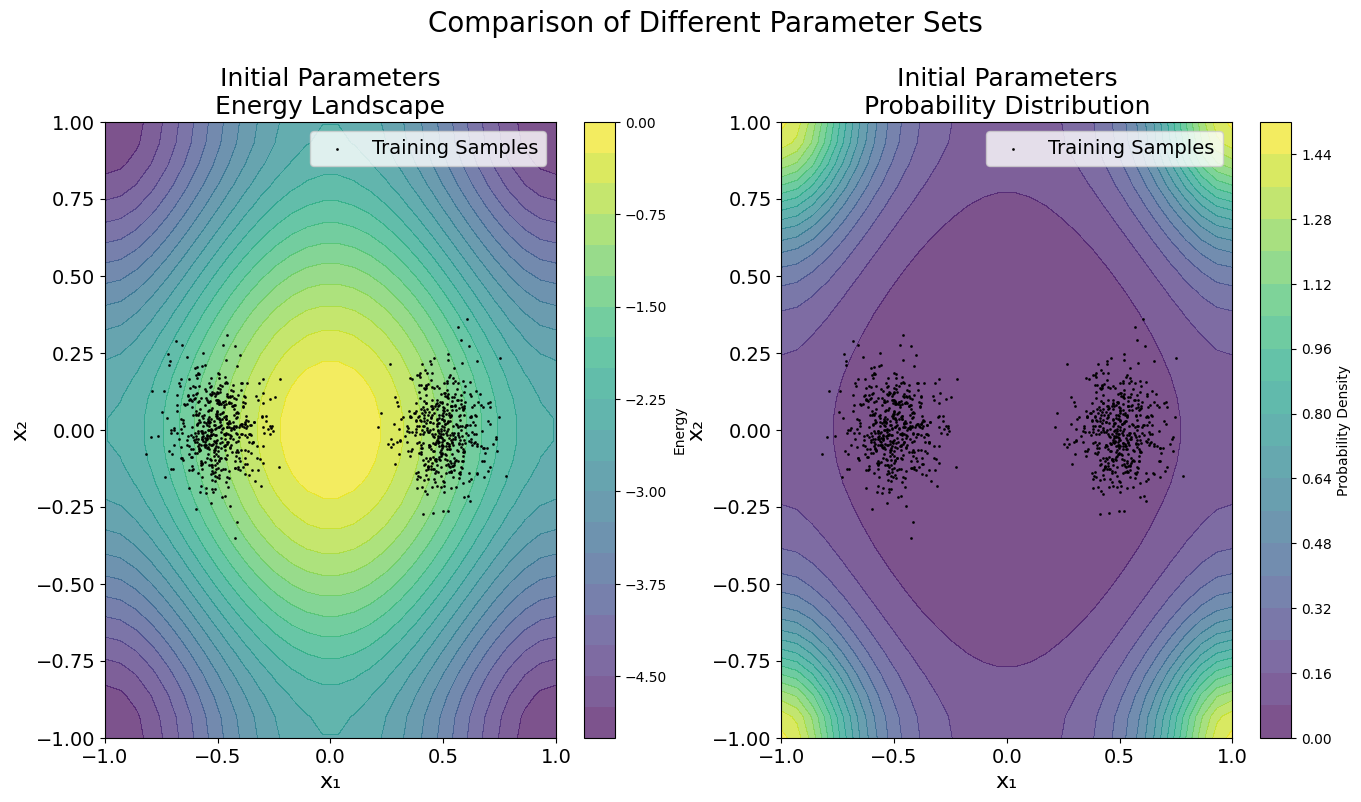

In [11]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

Optimizing for t = 0.000
Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 18.6997
---
Epoch 100
params:
[-0.59074239 -0.01473034  1.7685158   1.98006948  0.20372008 -0.06848372]
Loss: -11.4251
---
Epoch 200
params:
[-0.61878691  0.91973876  2.46508834  2.90324241  0.15071544 -0.08805521]
Loss: -24.0097
---
Epoch 300
params:
[-0.78613504  1.80130805  3.1831233   3.7876723   0.12816428 -0.14284208]
Loss: -33.0293
---
Epoch 400
params:
[-1.01102726  2.63954417  3.92054225  4.61517151  0.11267062 -0.11053872]
Loss: -44.2872
---
Epoch 500
params:
[-1.22314435  3.41578446  4.67030912  5.39390224  0.09847774 -0.17426949]
Loss: -49.4538
---
Epoch 600
params:
[-1.40824983  4.13783865  5.42223045  6.11691839  0.09554128 -0.1096404 ]
Loss: -60.2400
---
Epoch 700
params:
[-1.63126021  4.80564284  6.15106764  6.7766747   0.0863886  -0.11731819]
Loss: -62.0470
---
Epoch 800
params:
[-1.80629579  5.4172146   6.86866073  7.37704628  0.05263713 -0.17855065]
Loss: -66.0404
---
Epoch 900
param

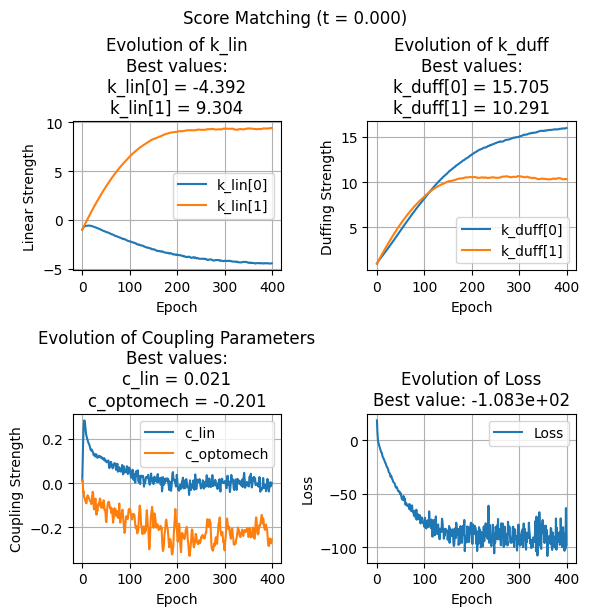

t = 0.000 probability distribution total (should be ≈ 1): 1.000000


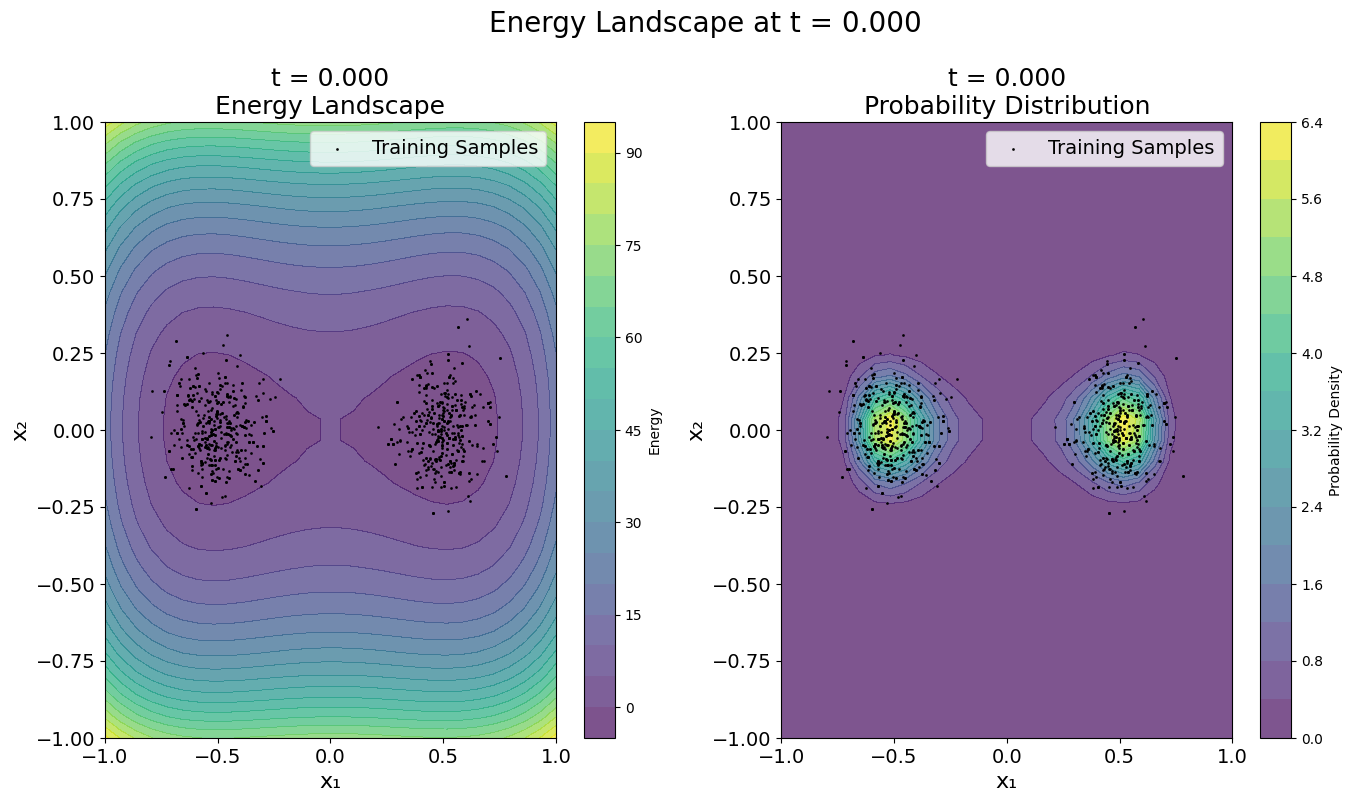

Optimizing for t = 0.022
Epoch 0
params:
[-4.40244353e+00  9.29357643e+00  1.56946772e+01  1.02809950e+01
  1.07238552e-02 -1.91001144e-01]
Loss: 349.3777
---
Epoch 100
params:
[-5.14321145  8.33663917 14.82601274  9.35838797 -0.655805    0.22252742]
Loss: 403.5714
---
Epoch 200
params:
[-5.36661407  7.475114   14.1479434   8.50231062 -0.61867257  0.34803795]
Loss: 241.1409
---
Epoch 300
params:
[-5.45916921  6.66058244 13.45918861  7.70310598 -0.49459597  0.3750762 ]
Loss: 131.1575
---
Epoch 400
params:
[-5.37834329  5.88852601 12.85640321  6.94555251 -0.34806513  0.40063683]
Loss: 132.4334
---
Epoch 500
params:
[-5.29863057  5.18844866 12.22786331  6.27904413 -0.29145775  0.22484979]
Loss: 258.4216
---
Epoch 600
params:
[-5.16065803  4.56205148 11.62405631  5.66473969 -0.22142411  0.29820825]
Loss: 187.8057
---
Epoch 700
params:
[-4.97263106  4.00702435 11.03429427  5.12394145 -0.15205319  0.22710509]
Loss: 67.4200
---
Epoch 800
params:
[-4.75047308  3.4958863  10.49408085  4.5919731

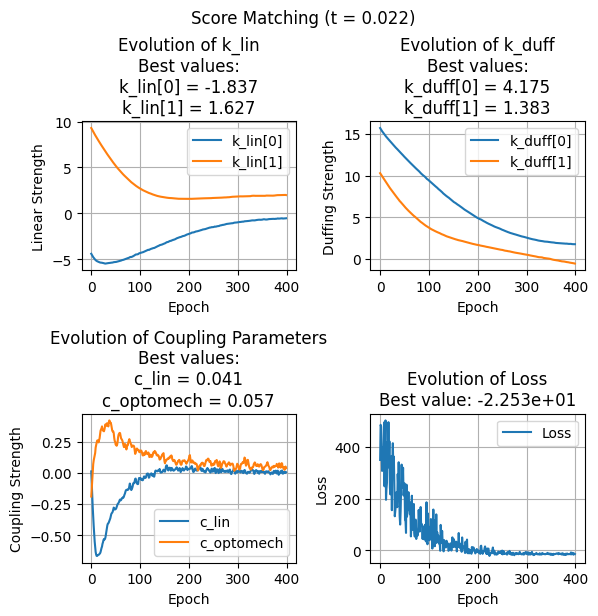

t = 0.022 probability distribution total (should be ≈ 1): 1.000000


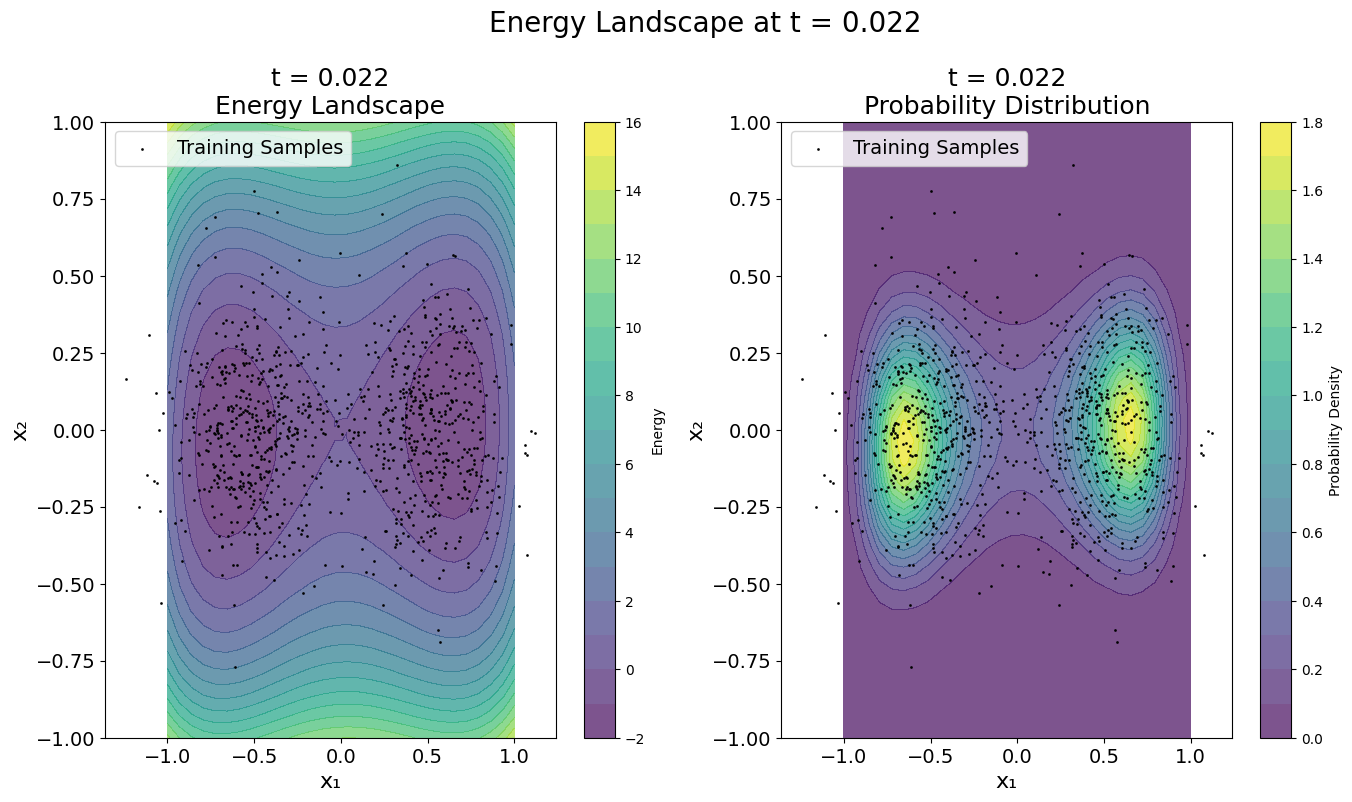

Optimizing for t = 0.044
Epoch 0
params:
[-1.84659719  1.61749512  4.16534407  1.37283626  0.03108096  0.04731987]
Loss: 14.1432
---
Epoch 100
params:
[-1.84647706  0.99313081  3.43541495  0.75469774 -0.008015   -0.05257109]
Loss: 14.0982
---
Epoch 200
params:
[-1.48760394  0.88330171  2.86277839  0.55749546  0.03488919 -0.05948378]
Loss: -7.4258
---
Epoch 300
params:
[-1.18544394  0.89458443  2.35281664  0.42800733  0.00892376 -0.04034119]
Loss: -7.1764
---
Epoch 400
params:
[-9.45983197e-01  9.55632999e-01  1.94548479e+00  3.98207446e-01
  4.04975820e-04 -2.32732566e-03]
Loss: -2.3901
---
Epoch 500
params:
[-0.69721563  0.99527649  1.59546162  0.28117348  0.01366938 -0.02145918]
Loss: -8.6478
---
Epoch 600
params:
[-0.5070417   1.00152425  1.33836366  0.22226351 -0.00678973 -0.00664   ]
Loss: -6.6273
---
Epoch 700
params:
[-0.3840546   1.02293263  1.15831877  0.15062405 -0.01107961 -0.04113733]
Loss: -9.4285
---
Epoch 800
params:
[-0.28977319  1.04393484  1.03750851  0.12744678 -0.02

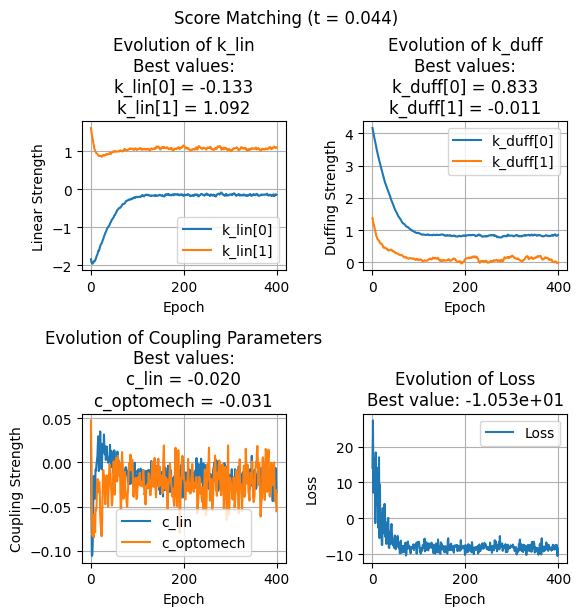

t = 0.044 probability distribution total (should be ≈ 1): 1.000000


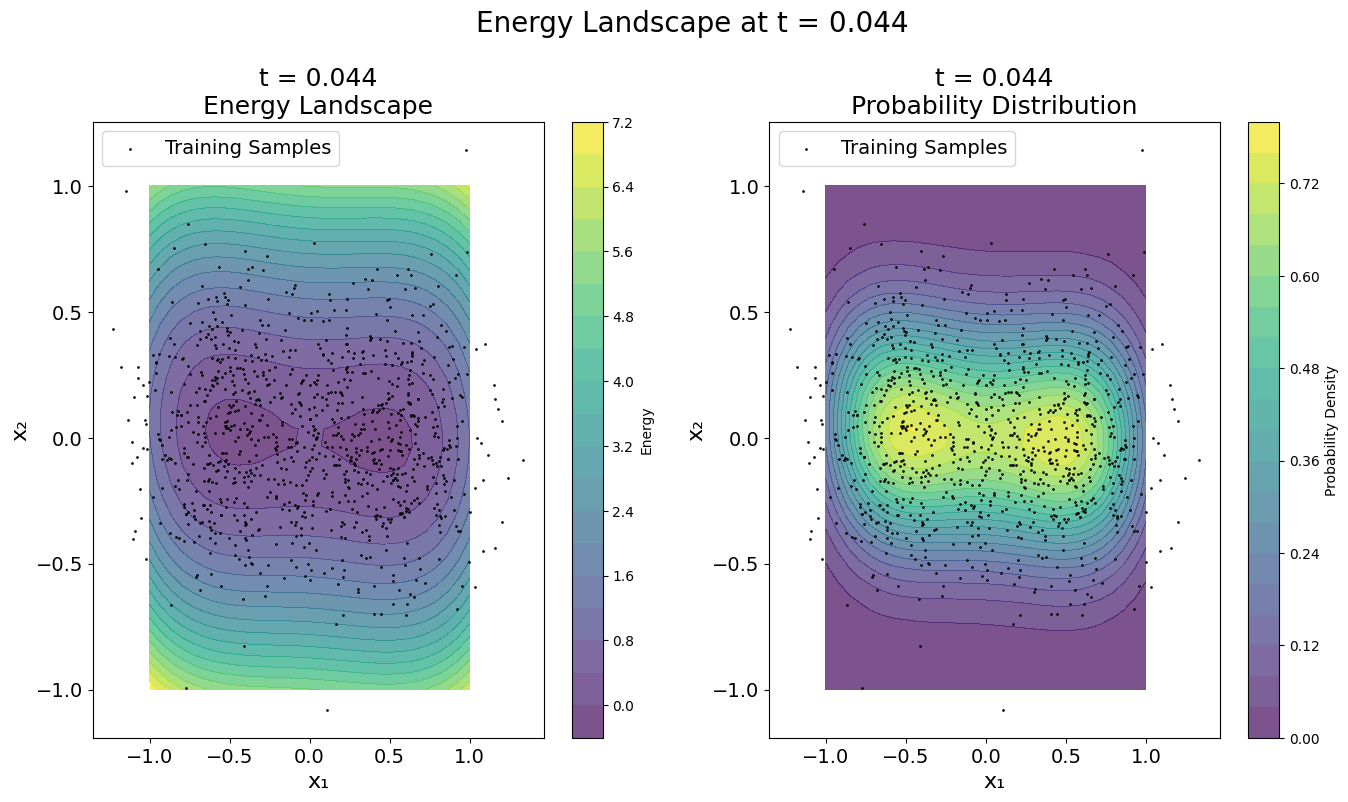

Optimizing for t = 0.067
Epoch 0
params:
[-0.1429582   1.08167568  0.82277598 -0.02078983 -0.0304733  -0.04121895]
Loss: -3.7447
---
Epoch 100
params:
[-0.034282    0.81872243  0.41814855 -0.13114156 -0.00362234  0.01280204]
Loss: -6.0649
---
Epoch 200
params:
[ 0.01604828  0.84028067  0.36296497 -0.05220782  0.01307485 -0.01111184]
Loss: -5.4085
---
Epoch 300
params:
[ 0.04072817  0.80045709  0.36255853 -0.0754834   0.00341488 -0.02688099]
Loss: -5.6999
---
Epoch 400
params:
[ 0.04687978  0.80105705  0.2994785  -0.0722308   0.0013709  -0.01098542]
Loss: -5.5918
---
Epoch 500
params:
[ 0.04257904  0.80760606  0.33786049 -0.09314706  0.00973522 -0.02162713]
Loss: -6.5326
---
Epoch 600
params:
[ 0.02439314  0.83488465  0.33446298 -0.04428245 -0.00530776  0.00181835]
Loss: -6.2135
---
Epoch 700
params:
[ 0.00774854  0.89123223  0.30769754 -0.0660185   0.012793    0.01341495]
Loss: -4.8543
---
Epoch 800
params:
[ 0.06899293  0.83832433  0.36308422 -0.10866711 -0.00902684 -0.02682003]
Loss:

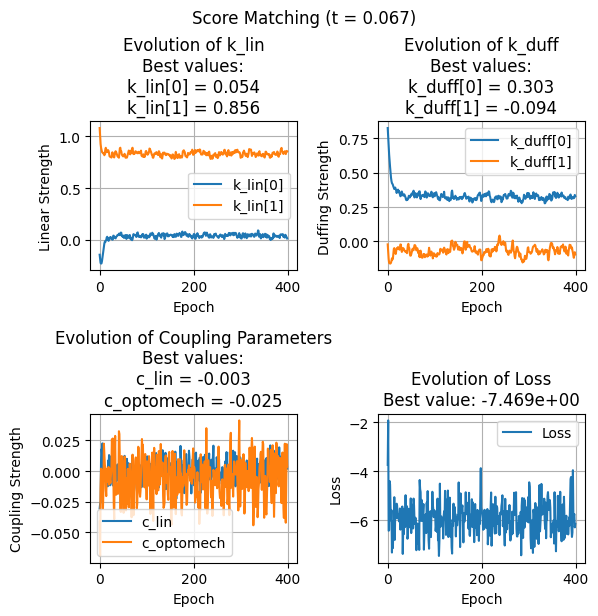

t = 0.067 probability distribution total (should be ≈ 1): 1.000000


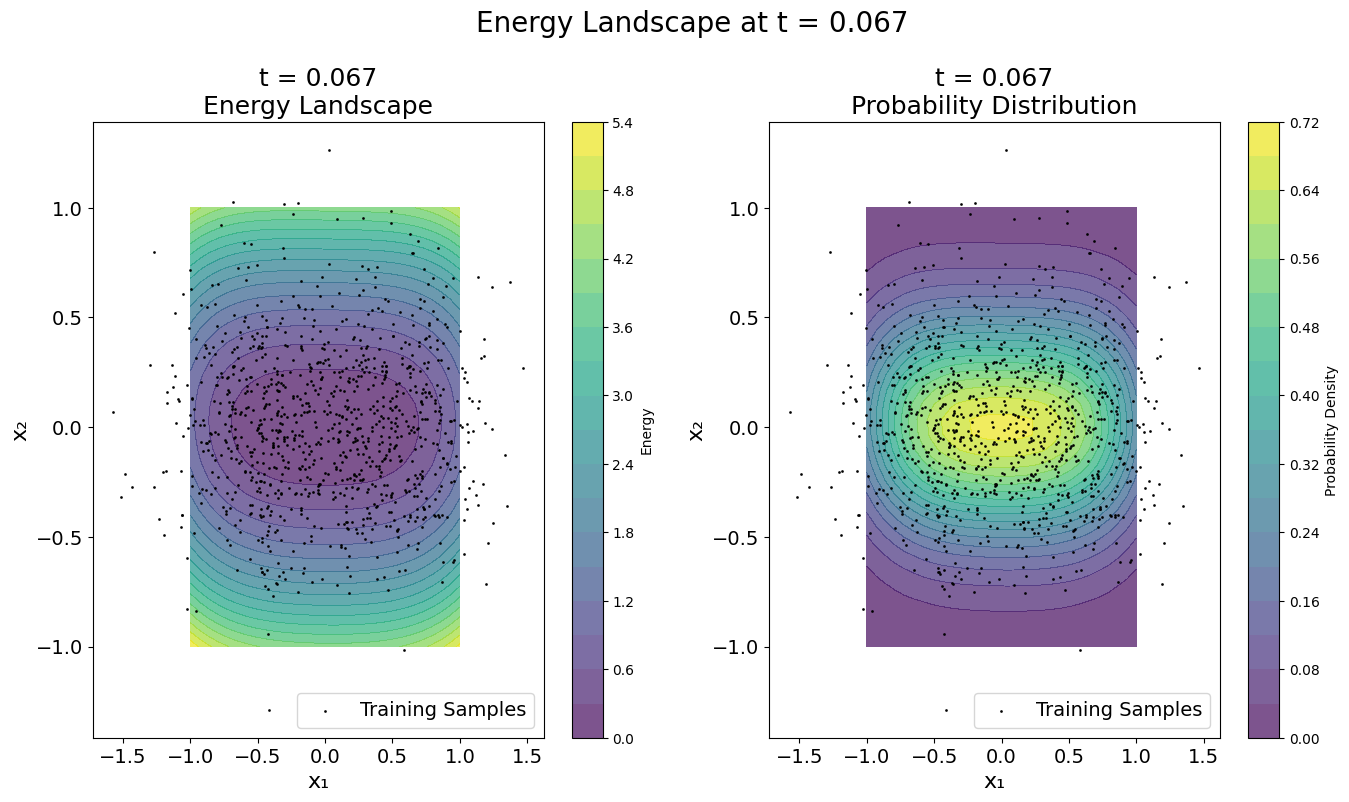

Optimizing for t = 0.089
Epoch 0
params:
[ 0.06389014  0.84561053  0.29304098 -0.10437607 -0.01298553 -0.0145408 ]
Loss: -3.3460
---
Epoch 100
params:
[ 0.1315856   0.71021555  0.1522401  -0.19662294  0.0126386  -0.00586905]
Loss: -4.8617
---
Epoch 200
params:
[ 0.11678616  0.70095808  0.12371181 -0.17887316  0.00135967 -0.02499821]
Loss: -4.4666
---
Epoch 300
params:
[ 0.11574507  0.7121338   0.14521017 -0.18168599  0.01251924  0.01268766]
Loss: -3.6655
---
Epoch 400
params:
[ 0.14363562  0.6995393   0.1588246  -0.18028499 -0.00411261  0.02291023]
Loss: -4.3436
---
Epoch 500
params:
[ 0.12117679  0.69055296  0.11968862 -0.13682395  0.00382484 -0.0081885 ]
Loss: -4.0642
---
Epoch 600
params:
[ 1.40472551e-01  7.17024048e-01  2.00514681e-01 -1.80045329e-01
 -4.64900545e-03  6.22617883e-04]
Loss: -4.6322
---
Epoch 700
params:
[ 0.13455345  0.68094788  0.1553414  -0.17383436 -0.00549086  0.01717599]
Loss: -4.7639
---
Epoch 800
params:
[ 0.11501894  0.71798029  0.13911965 -0.18643693 -0.01

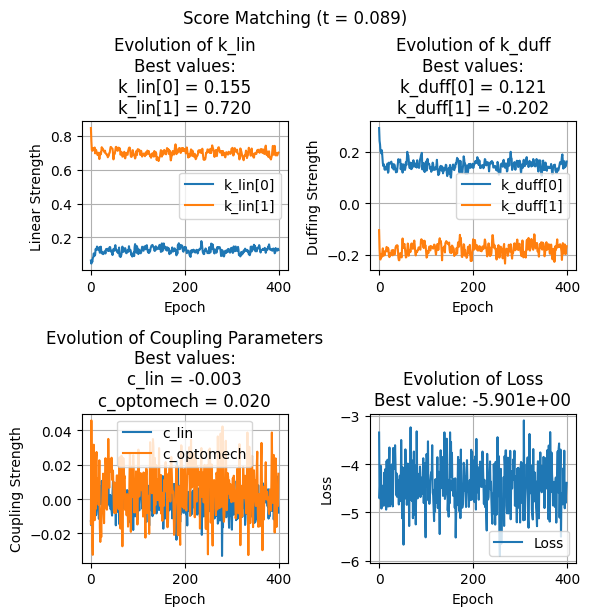

t = 0.089 probability distribution total (should be ≈ 1): 1.000000


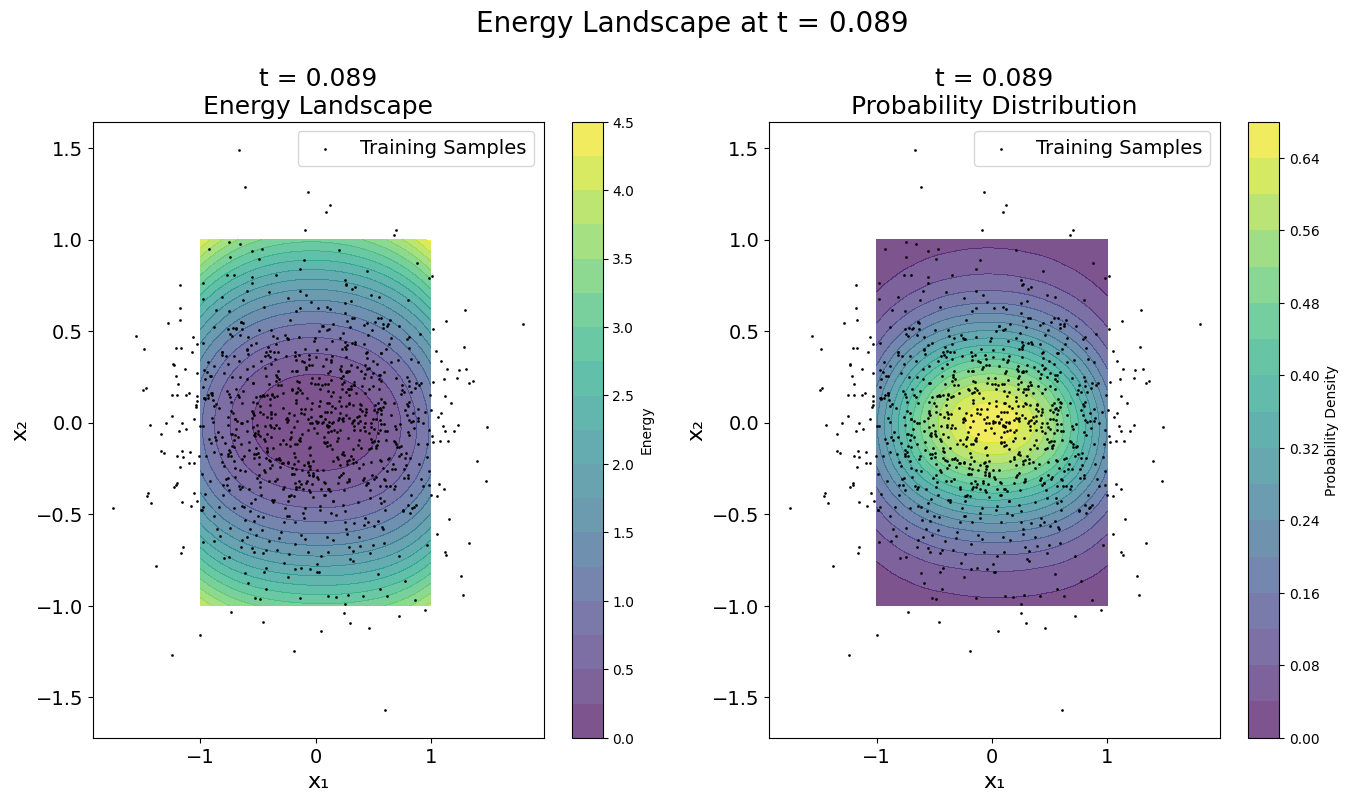

Optimizing for t = 0.111
Epoch 0
params:
[ 0.14457128  0.70962967  0.13136281 -0.21187197 -0.01337639  0.01012993]
Loss: -3.5887
---
Epoch 100
params:
[ 0.10017371  0.45364206  0.16316428 -0.03055287  0.00093702 -0.01641082]
Loss: -4.2381
---
Epoch 200
params:
[ 0.10748805  0.45108683  0.16695591 -0.01061272 -0.00588011 -0.00545152]
Loss: -3.9097
---
Epoch 300
params:
[ 0.12712762  0.47052286  0.14169378  0.01389936 -0.0099645  -0.00556613]
Loss: -3.8924
---
Epoch 400
params:
[ 9.13782145e-02  4.92799545e-01  1.68608020e-01  1.80775574e-02
 -2.97338925e-04 -9.36991362e-03]
Loss: -3.5567
---
Epoch 500
params:
[ 0.11573219  0.47743308  0.163284    0.00445116 -0.00721065 -0.01143572]
Loss: -3.3638
---
Epoch 600
params:
[ 0.10293337  0.47908008  0.15048435  0.00177676 -0.01066695 -0.01701808]
Loss: -3.8881
---
Epoch 700
params:
[ 0.10970243  0.44909186  0.15204771  0.01881396  0.00239375 -0.01901981]
Loss: -3.8666
---
Epoch 800
params:
[ 0.08738173  0.4636827   0.19955928 -0.0079388  -0.00

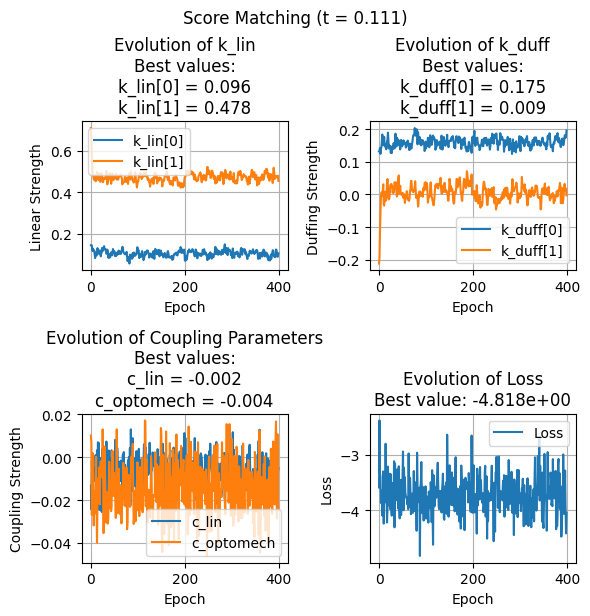

t = 0.111 probability distribution total (should be ≈ 1): 1.000000


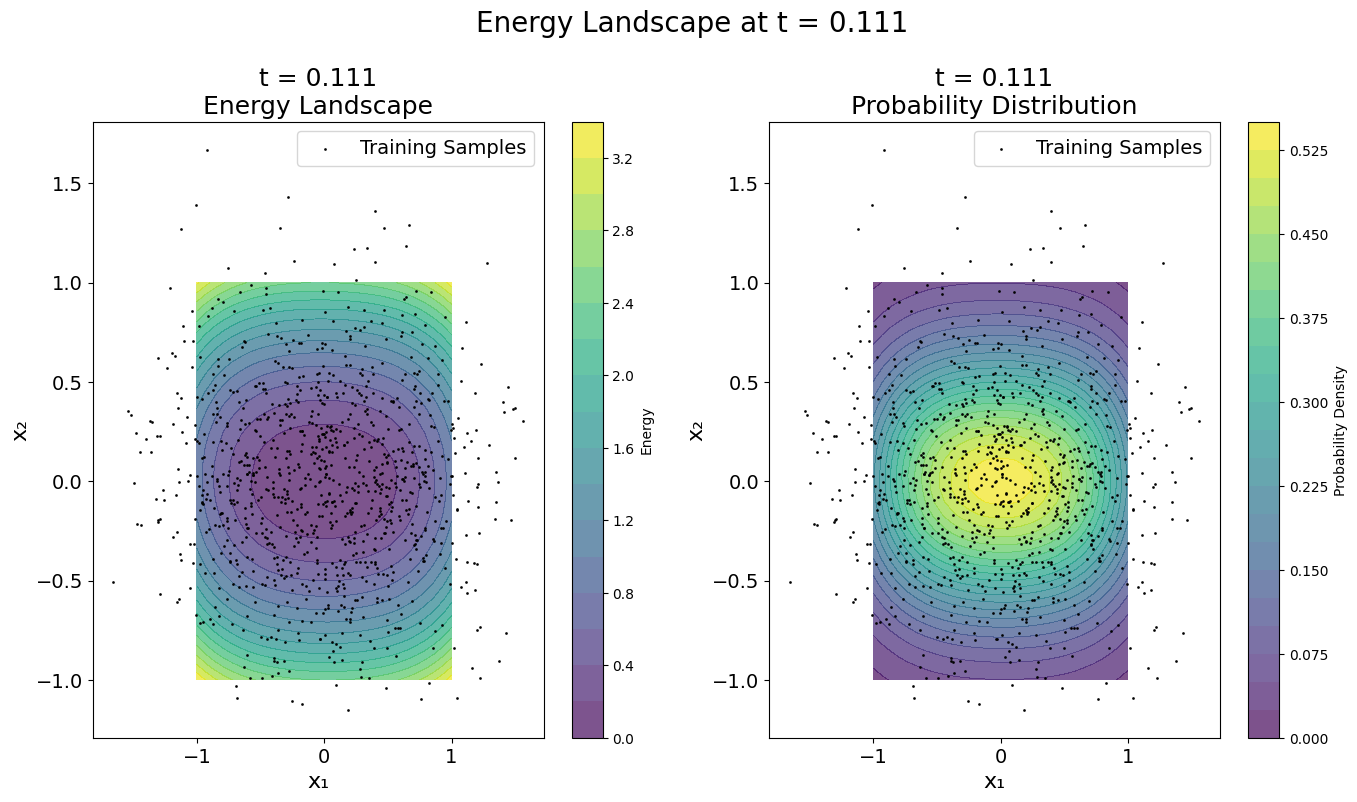

Optimizing for t = 0.133
Epoch 0
params:
[ 0.08596787  0.46800018  0.16463701 -0.00064009 -0.01152471 -0.01379715]
Loss: -3.0016
---
Epoch 100
params:
[ 0.16161123  0.37476725  0.07355871  0.02347706 -0.00693863  0.00863463]
Loss: -3.1737
---
Epoch 200
params:
[ 0.14916529  0.3619139   0.06200279 -0.01796022  0.00857464 -0.03620935]
Loss: -2.9565
---
Epoch 300
params:
[ 0.15675942  0.39051604  0.06009622  0.00546228  0.01211087 -0.00647001]
Loss: -3.3973
---
Epoch 400
params:
[ 0.14336615  0.37199587  0.07127741 -0.00963134 -0.00103434 -0.0414789 ]
Loss: -3.0162
---
Epoch 500
params:
[ 0.15925381  0.40762826  0.05719338 -0.03078575 -0.0007868  -0.01306501]
Loss: -3.0454
---
Epoch 600
params:
[ 0.15083373  0.36522211  0.04722613 -0.0296593  -0.00584531 -0.01167289]
Loss: -2.9750
---
Epoch 700
params:
[ 0.12488729  0.37478016  0.0832867  -0.00368291  0.00469631 -0.03307313]
Loss: -3.0879
---
Epoch 800
params:
[ 0.14890517  0.37780568  0.05701677  0.02187992  0.0086148  -0.01365204]
Loss:

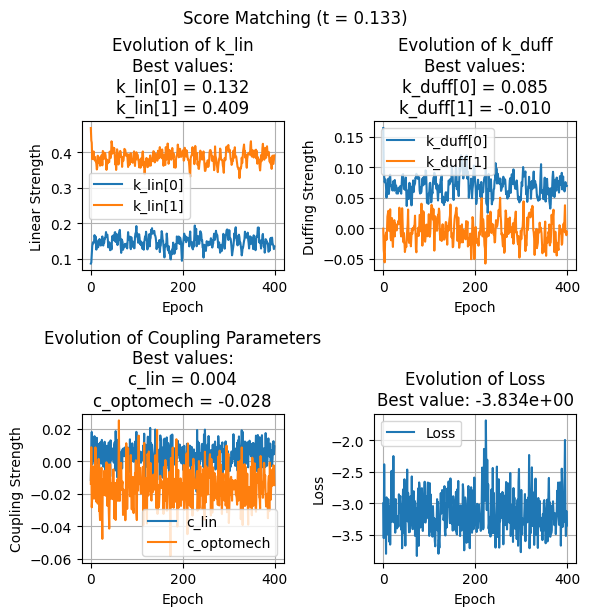

t = 0.133 probability distribution total (should be ≈ 1): 1.000000


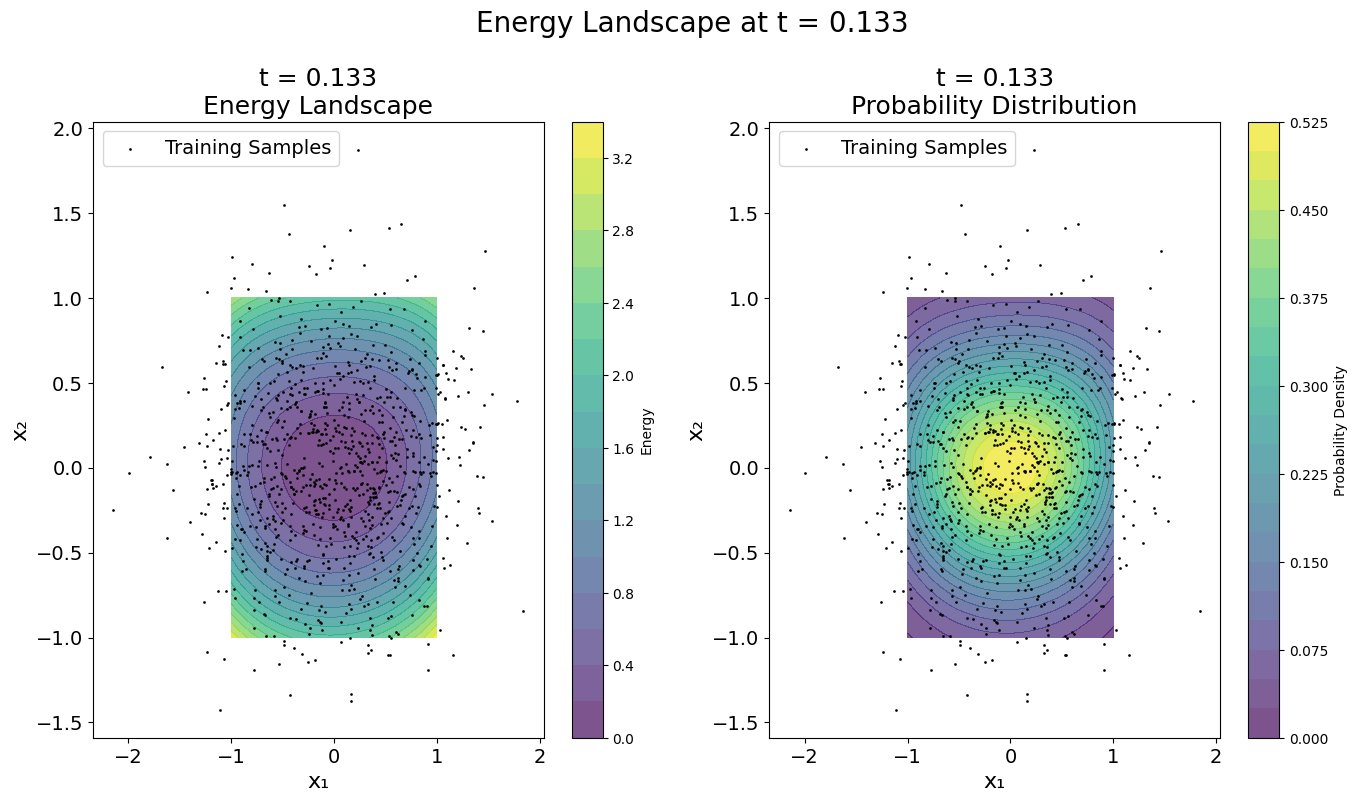

Optimizing for t = 0.156
Epoch 0
params:
[ 0.12180129  0.39922336  0.07503894 -0.02047806 -0.00620392 -0.01779194]
Loss: -2.5901
---
Epoch 100
params:
[ 0.17039041  0.38824698  0.02451001 -0.02232949 -0.00577542  0.03693512]
Loss: -3.1811
---
Epoch 200
params:
[ 0.1724108   0.40440506  0.04415179 -0.01421533 -0.00904697  0.00656274]
Loss: -3.0645
---
Epoch 300
params:
[ 0.1691903   0.37615693  0.05186705  0.02214081 -0.00939225  0.0022584 ]
Loss: -2.5444
---
Epoch 400
params:
[ 0.14665524  0.40644345  0.02353081 -0.03271997  0.00166499  0.00680263]
Loss: -2.7999
---
Epoch 500
params:
[ 1.60147179e-01  4.21808176e-01  2.13188056e-02 -2.28652467e-02
  7.02728741e-05  1.24169976e-02]
Loss: -3.4623
---
Epoch 600
params:
[ 0.17146664  0.37205641  0.01511889 -0.02781371  0.00744741  0.0150906 ]
Loss: -3.0985
---
Epoch 700
params:
[ 0.17165499  0.38881796  0.03567733 -0.00165074  0.001595    0.01079301]
Loss: -3.4118
---
Epoch 800
params:
[ 0.17158162  0.38389323  0.0405899  -0.01484981 -0.00

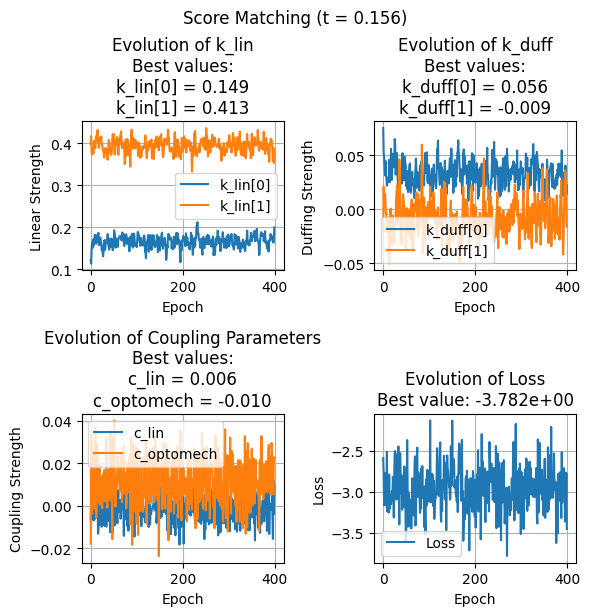

t = 0.156 probability distribution total (should be ≈ 1): 1.000000


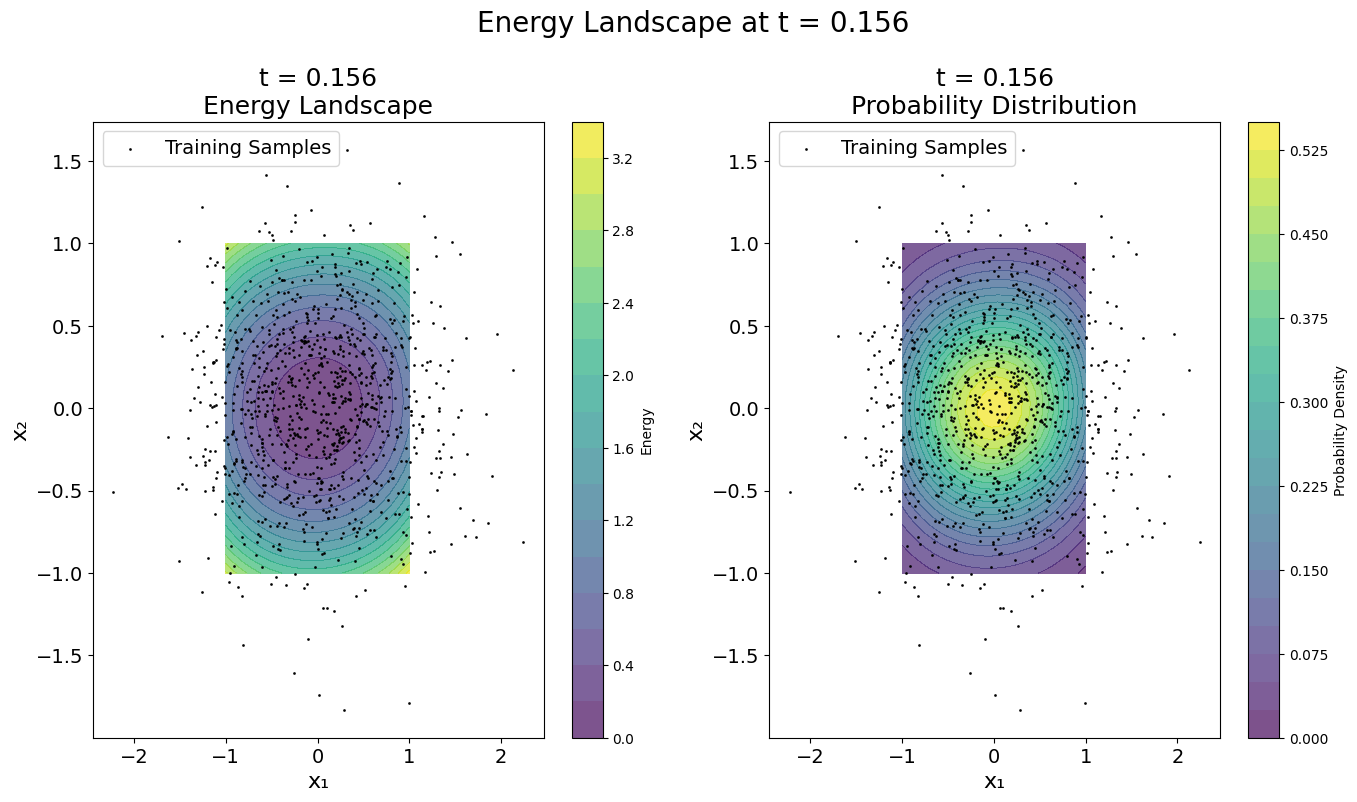

Optimizing for t = 0.178
Epoch 0
params:
[ 0.13856557  0.40337804  0.04579129 -0.01911255 -0.00415827 -0.00045746]
Loss: -2.2452
---
Epoch 100
params:
[ 0.14164318  0.2745332   0.03757202  0.02177232 -0.00681807  0.02716958]
Loss: -2.6423
---
Epoch 200
params:
[ 0.14846328  0.32069489  0.06657688  0.02522833 -0.00495141  0.00327094]
Loss: -3.0111
---
Epoch 300
params:
[ 0.13150028  0.28481896  0.05972879  0.01774455 -0.00332313  0.00996953]
Loss: -2.8353
---
Epoch 400
params:
[ 0.16183267  0.32468375  0.02460269  0.0452485  -0.00646713 -0.00775787]
Loss: -2.6412
---
Epoch 500
params:
[0.14437253 0.28381184 0.02857843 0.03124646 0.00247776 0.01608259]
Loss: -2.8960
---
Epoch 600
params:
[0.17425557 0.31618034 0.03694123 0.04486586 0.00563495 0.00446295]
Loss: -2.2274
---
Epoch 700
params:
[ 0.17891358  0.28892703  0.03411825  0.02715728 -0.00205371  0.02097351]
Loss: -2.6196
---
Epoch 800
params:
[1.41793386e-01 3.01023002e-01 5.01379539e-02 1.44853455e-02
 8.72510845e-05 1.88506357e-02

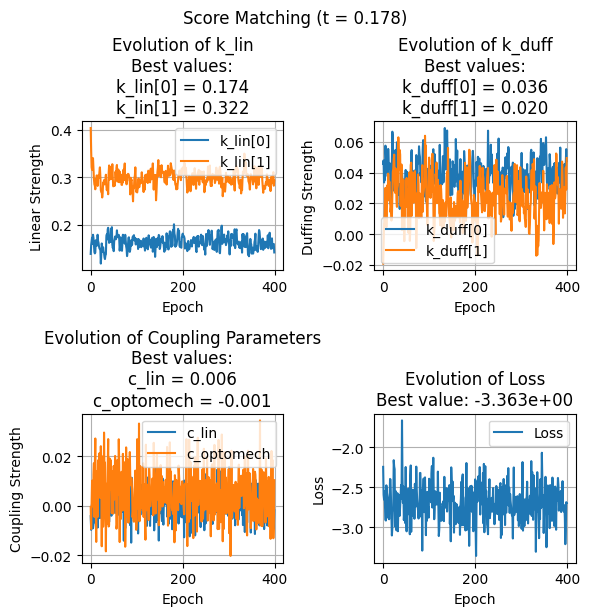

t = 0.178 probability distribution total (should be ≈ 1): 1.000000


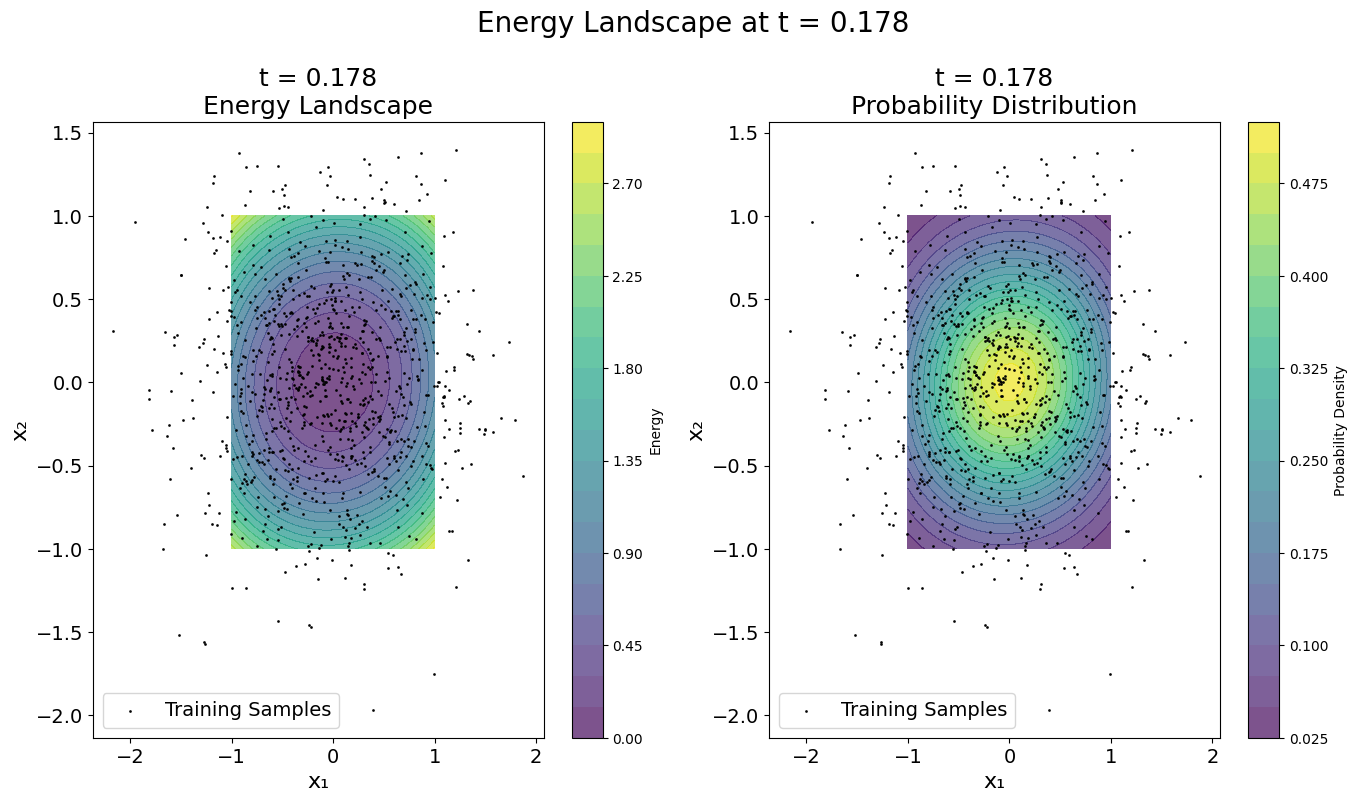

Optimizing for t = 0.200
Epoch 0
params:
[ 0.16405084  0.33248843  0.04597589  0.01041616 -0.00358748  0.00928183]
Loss: -2.9533
---
Epoch 100
params:
[ 0.21847974  0.27972127 -0.00961848  0.05835019  0.0116232   0.01708303]
Loss: -2.1806
---
Epoch 200
params:
[ 0.20405043  0.27506123  0.00069502  0.07792811 -0.00100744 -0.00218055]
Loss: -2.4103
---
Epoch 300
params:
[ 0.23517806  0.26791561  0.0028333   0.05903785 -0.00732551 -0.0165246 ]
Loss: -2.8307
---
Epoch 400
params:
[0.20732873 0.2736346  0.00537756 0.0650743  0.00272996 0.00162959]
Loss: -2.5675
---
Epoch 500
params:
[0.20392059 0.28491381 0.00683885 0.04926591 0.00109322 0.00695046]
Loss: -2.6010
---
Epoch 600
params:
[0.18304729 0.26354898 0.00700552 0.06721736 0.00116504 0.01896983]
Loss: -2.7458
---
Epoch 700
params:
[0.18508194 0.26006296 0.01282541 0.06319169 0.00666255 0.01047563]
Loss: -2.9603
---
Epoch 800
params:
[ 0.20708212  0.27976188 -0.01233081  0.04604546  0.00990646  0.00421681]
Loss: -2.5117
---
Epoch 900
p

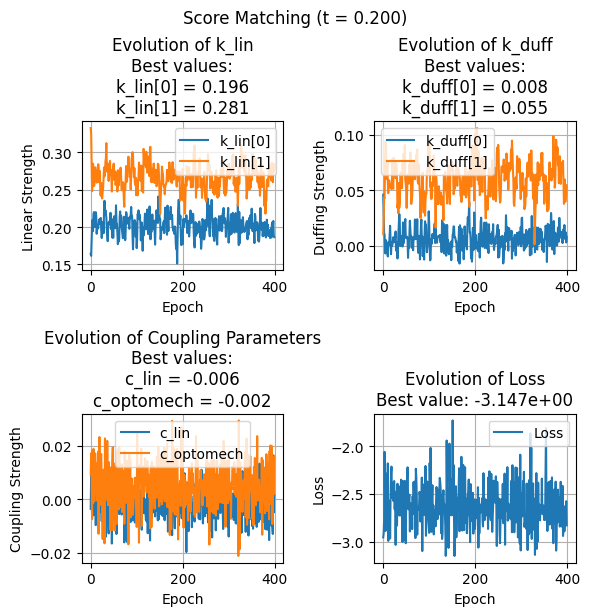

t = 0.200 probability distribution total (should be ≈ 1): 1.000000


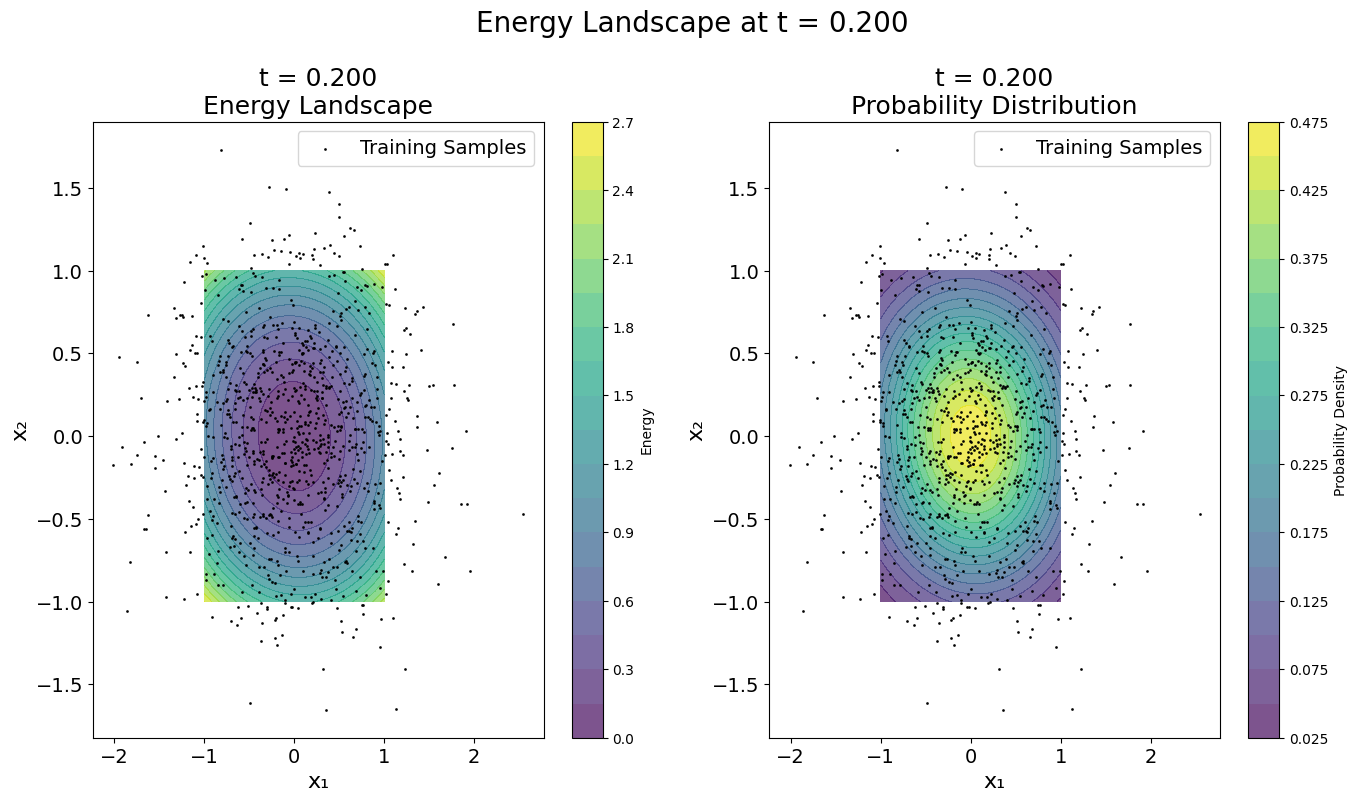

In [12]:
# Setup optimization parameters
n_time_steps = 10
forward_time_pts = jnp.linspace(0., .2, n_time_steps)
learning_rate = 0.01
n_epochs = 4000
batch_size = 128

# Initialize storage for parameters at each time step
params_history_all_t = []
current_params = flattened_args_initial

# Loop over time points
for t_idx, t_forward in enumerate(forward_time_pts):
    print(f"Optimizing for t = {t_forward:.3f}")
    
    # Generate samples at current time
    key, subkey = jr.split(key)
    samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(
        t_forward, n_samples, D=1, samples0=samples_0, key=subkey
    )
    
    # Perform optimization starting from previous best parameters
    key, subkey = jr.split(key)
    loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
    params_history_SM, loss_history_SM = run_optimization(
        loss_fn_per_batch=loss_fn_per_batch_SM,
        params_initial=current_params,
        samples=samples_t,
        gradient_fn_per_batch=None,
        key=subkey,
        batch_size=batch_size,
        learning_rate=learning_rate,
        n_epochs=n_epochs
    )
    
    # Plot optimization progress
    k_lin_best, k_duff_best, c_lin_best, c_optomech_best = plot_parameter_evolution(
        params_history=params_history_SM,
        loss_history=loss_history_SM,
        unflatten=unflatten,
        N_osc=N_osc,
        slicing=10,
        title=f"Score Matching (t = {t_forward:.3f})"
    )
    
    # Store best parameters and update current_params for next iteration
    args_best_sm = (k_lin_best, k_duff_best, c_lin_best, c_optomech_best)
    current_params, _ = flatten_util.ravel_pytree(args_best_sm)
    params_history_all_t.append(current_params)
    
    # Plot current energy landscape
    plot_energy_and_distributions(
        energy_fn=energy_fn,
        param_list=[current_params],
        samples=samples_t,
        x1_range=(-1, 1),
        x2_range=(-1, 1),
        n_points=30,
        titles=[f"t = {t_forward:.3f}"],
        fontsize=16,
        sample_stride=1,
        suptitle=f"Energy Landscape at t = {t_forward:.3f}"
    )

# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)


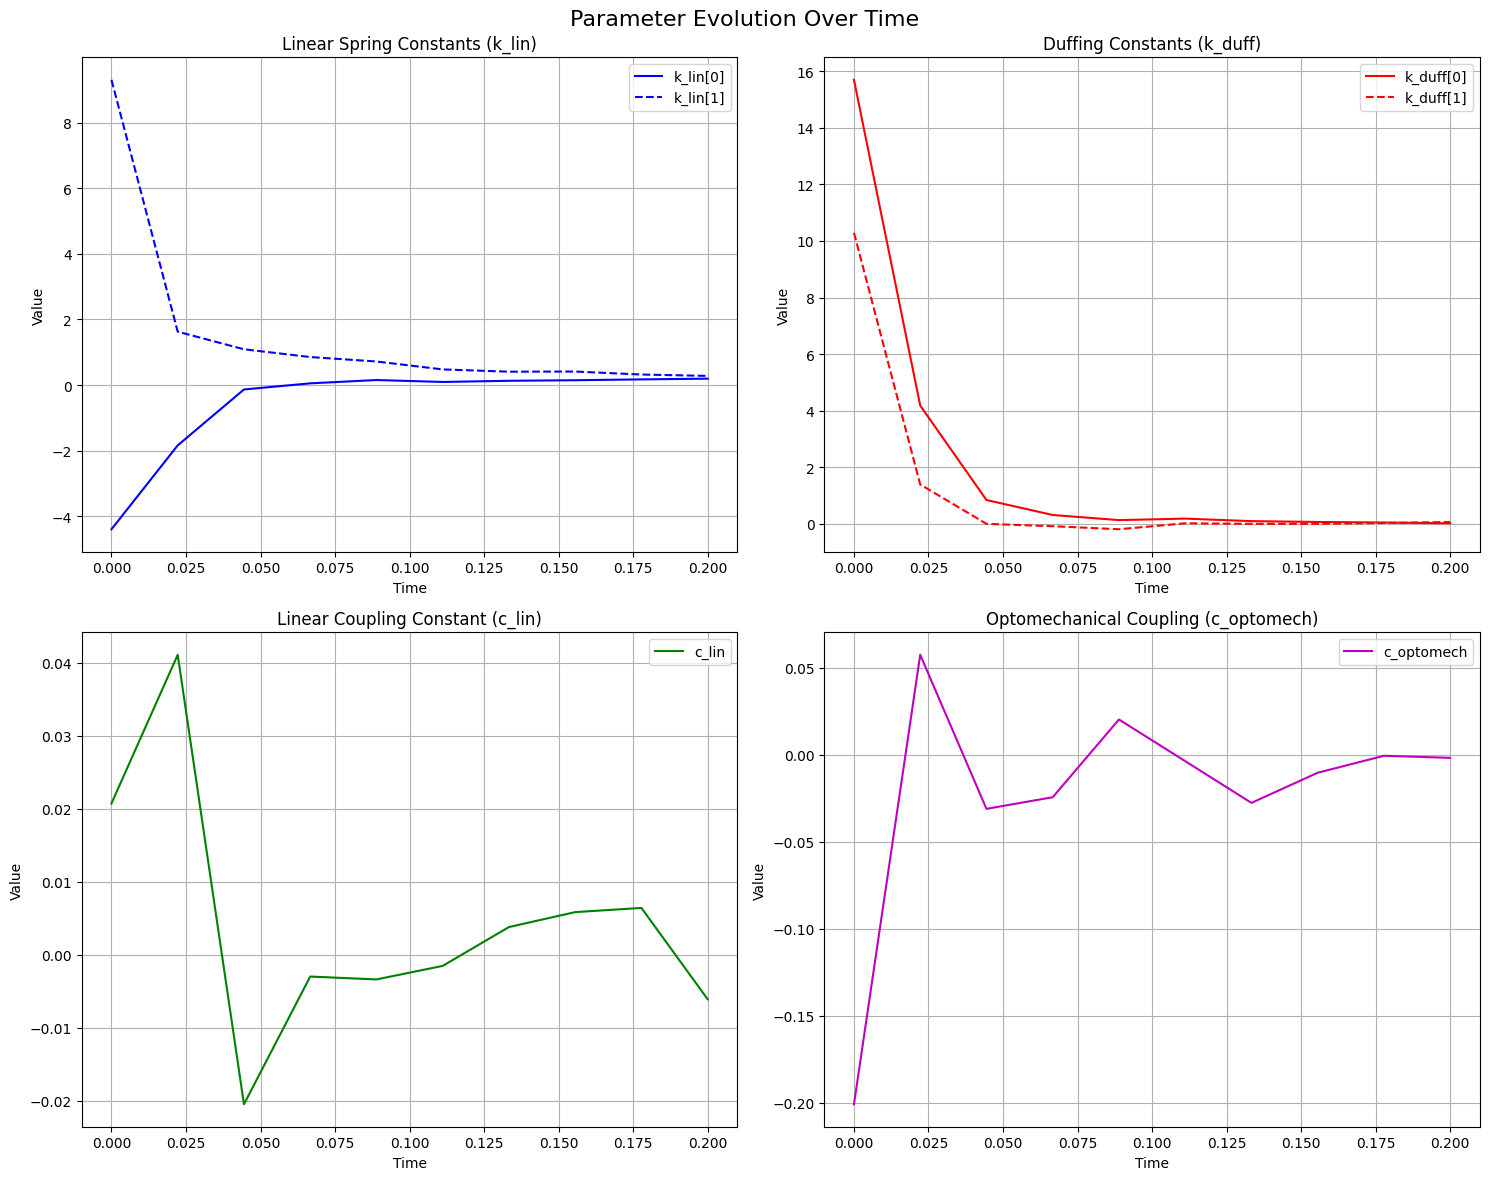

In [13]:
# Create a figure with subplots for each parameter type
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time', fontsize=16)

# Time points
time_points = forward_time_pts

# Plot k_lin parameters
ax1.plot(time_points, params_history_all_t[:, 0], 'b-', label='k_lin[0]')
ax1.plot(time_points, params_history_all_t[:, 1], 'b--', label='k_lin[1]')
ax1.set_title('Linear Spring Constants (k_lin)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True)

# Plot k_duff parameters
ax2.plot(time_points, params_history_all_t[:, 2], 'r-', label='k_duff[0]')
ax2.plot(time_points, params_history_all_t[:, 3], 'r--', label='k_duff[1]')
ax2.set_title('Duffing Constants (k_duff)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True)

# Plot c_lin parameter
ax3.plot(time_points, params_history_all_t[:, 4], 'g-', label='c_lin')
ax3.set_title('Linear Coupling Constant (c_lin)')
ax3.set_xlabel('Time')
ax3.set_ylabel('Value')
ax3.legend()
ax3.grid(True)

# Plot c_optomech parameter
ax4.plot(time_points, params_history_all_t[:, 5], 'm-', label='c_optomech')
ax4.set_title('Optomechanical Coupling (c_optomech)')
ax4.set_xlabel('Time')
ax4.set_ylabel('Value')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

### Contrastive Divergence 1

In [ ]:
# Define optimization parameters
learning_rate = learning_rate
n_epochs = n_epochs
batch_size = batch_size
loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
key, subkey = jr.split(key)
cd1_grad = lambda params, batch: -CD1_gradient(energy_fn, 
                                               batch, 
                                               params, 
                                               dt=0.001, 
                                               D=1, 
                                               key=key, 
                                               num_noise_samples=100)

params_history_cd1, loss_history_cd1 = run_optimization(loss_fn_per_batch = loss_fn_per_batch_SM, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples, 
                                                        gradient_fn_per_batch = cd1_grad, 
                                                        key=subkey,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs)

In [ ]:
k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1 = plot_parameter_evolution(
    params_history=params_history_cd1,
    loss_history=loss_history_cd1,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="CD1"
)
args_best_cd1 = (k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1)
flattened_args_best_cd1, _ = flatten_util.ravel_pytree(args_best_cd1)


### MLE

In [ ]:
# Define optimization parameters
learning_rate = .5
n_epochs = 100
batch_size = samples.shape[0]//2
key, subkey = jr.split(key)
loss_fn_per_batch_MLE = setup_MLE_loss_per_batch(energy_fn)
gradient_fn_per_batch_MLE = setup_MLE_gradient_per_batch(energy_fn, 
                                                     N_osc, 
                                                     gamma=1.0, 
                                                     k_b=1.0, 
                                                     T=1.0, 
                                                     t0=0.0, 
                                                     t1=10.0, 
                                                     N_samples=1000, 
                                                     dt0=0.01, 
                                                     initial_state=jnp.array([0.,0.]))

params_history_mle, loss_history_mle = run_optimization(loss_fn_per_batch = loss_fn_per_batch_MLE, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples,
                                                        gradient_fn_per_batch = gradient_fn_per_batch_MLE, 
                                                        key=key,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs, 
                                                        maximize=True)

In [ ]:
k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle = plot_parameter_evolution(
    params_history=params_history_mle,
    loss_history=loss_history_mle,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=1,
    title="MLE",
    maximize=True
)
args_best_mle = (k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle)
flattened_args_best_mle, _ = flatten_util.ravel_pytree(args_best_mle)

### Compare solutions

In [ ]:
# Example usage:
param_list = [flattened_args_initial, flattened_args_best_sm, flattened_args_best_cd1, flattened_args_best_mle]
titles = ["Initial Parameters", "Score Matching Best", "CD-1 Best", "MLE Best"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    
    x2_range=(-1, 1),    
    n_points=30,        
    titles=titles,       
    figsize=None,    
    fontsize=16,
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets"  
)

### Run the SDE on one of the optimized energy landscape

In [25]:
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, flattened_args_best_sm, N_osc)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 10000)
dt0 = ts[1] - ts[0]
initial_state    = jnp.array([0.,0.])

solution = solve_SDE(drift_fn, diffusion_fn, initial_state, t0, t1, ts.shape[0], dt0)
sde_samples = solution.ys

In [ ]:
# Example usage:
param_list = [flattened_args_best_sm]
titles = ["Score Matching Best Energy "]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples,
    sample_stride=1,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Energy landscape with SDE samples"  # optional
)